In [20]:
import jax
import jax.numpy as jnp
import numpy as np
from jax import random, jit, vmap
from dataclasses import dataclass
from typing import Any
import matplotlib.pyplot as plt
import mcfile as mcf
import pickle

In [50]:
# ─── Primitives ───────────────────────────────────────────────────────────────
@jit
def sigmoid(x):
    return 1 / (1 + jnp.exp(-x))

@jit
def free_energy(W, bv, bh, v):
    """F(v; θ) per sample. Shape: (batch,)"""
    visible_term = jnp.dot(v, bv)
    hidden_input = jnp.dot(v, W.T) + bh
    # jnp.logaddexp(0, x) is the stable equivalent of log(1 + exp(x))
    hidden_term  = jnp.logaddexp(0, hidden_input).sum(axis=1)
    return -visible_term - hidden_term

@jit
def hidden_probs(W, bh, v):
    return sigmoid(jnp.dot(v, W.T) + bh)

@jit
def visible_probs(W, bv, h):
    return sigmoid(jnp.dot(h, W) + bv)

@jit
def sample(probs, key):
    return (random.uniform(key, shape=probs.shape) < probs).astype(jnp.float32)

# ─── Pseudo-Likelihood ────────────────────────────────────────────────────────

@jit
def pseudo_likelihood(W, bv, bh, v):
    """Computes the log pseudo-likelihood log PL(v) for a batch of visible vectors.
    
    PL(v) = \prod_{i} P(v_i | v_{-i})
    We use the efficient formula: P(v_i=1 | v_{-i}) = sigmoid(bv_i + \sum_j W_{ji} * hidden_activation)
    """
    # 1. Compute the effective input to the hidden layer from the visible state
    hidden_input = jnp.dot(v, W.T) + bh  # Shape: (batch, n_hidden)
    
    # 2. For each visible unit i, compute the log P(v_i | v_{-i})
    # We can vectorize this over all visible units i using matrix operations.
    # The term (v @ W.T) contains the contribution of all bits. To isolate v_{-i}, 
    # we can compute how the hidden activation changes when flipping the i-th bit.
    
    # To avoid explicit looping, we exploit the RBM structure: 
    # F(v with v_i=1) - F(v with v_i=0) = -bv_i - \sum_j log(1 + exp(W_ji + input_without_i))
    # Alternatively, an exact conditional distribution for bit i is:
    # P(v_i = 1 | v_{-i}) = sigmoid( bv_i + \sum_j log [ (1 + exp(W_ji + x_j - W_ji v_i)) / (1 + exp(x_j - W_ji v_i)) ] )
    
    # A standard fast approximation/exact trick for binary RBMs:
    # Compute free energy of original v, and free energy of v with bit i flipped.
    # Let's use vmap over the visible dimension to compute the flipped states quickly.
    n_visible = W.shape[1]
    batch_size = v.shape[0]
    
    def pl_for_unit(i):
        # Flip the i-th bit of the entire batch
        mask = jnp.zeros((n_visible,), dtype=jnp.float32).at[i].set(1.0)
        v_flipped = v + (1.0 - 2.0 * v) * mask  # flips 0->1 and 1->0
        
        fe_orig = free_energy(W, bv, bh, v)
        fe_flipped = free_energy(W, bv, bh, v_flipped)
        
        # P(v_i | v_{-i}) = exp(-F(v)) / (exp(-F(v)) + exp(-F(v_flipped)))
        #                 = 1 / (1 + exp(F(v) - F(v_flipped)))
        #                 = sigmoid(F(v_flipped) - F(v))
        # However, we only want the probability of the *observed* value of v_i.
        # If observed v_i == v_flipped_i (not possible), but conceptually:
        # log P(v_i) = - log(1 + exp(F(orig) - F(flipped))) if orig matches target.
        # Clean formulation: log P(v_i | v_{-i}) = -logaddexp(0, fe_orig - fe_flipped)
        return -jnp.logaddexp(0, fe_orig - fe_flipped)

    # vmap over the visible unit indices (axis 0 of the output)
    log_p_vi = vmap(pl_for_unit)(jnp.arange(n_visible)) # Shape: (n_visible, batch)
    
    # Sum across all visible units to get log PL for each sample, then mean over batch
    return log_p_vi.sum(axis=0)

# ─── Initialisation ───────────────────────────────────────────────────────────

def init_rbm(n_visible, n_hidden, key):
    k1, k2 = random.split(key)
    scale = jnp.sqrt(2 / (n_visible + n_hidden))
    W  = random.normal(k1, (n_hidden, n_visible)).astype(jnp.float32) * scale
    bv = jnp.zeros(n_visible, dtype=jnp.float32)
    bh = jnp.zeros(n_hidden,  dtype=jnp.float32)
    
    # Return k2 as the "new" key for the caller to use next
    return W, bv, bh, k2

def init_chains(n_chains, n_visible, key):
    k1, k2 = random.split(key)
    chains = random.randint(k1, (n_chains, n_visible), 0, 2).astype(jnp.float32)
    return chains, k2

# ─── PCD step ─────────────────────────────────────────────────────────────────

@jit
def pcd_step(W, bv, bh, v0, chains, lr, weight_decay, key):
    k1, k2 = random.split(key)

    # Positive phase
    ph0 = hidden_probs(W, bh, v0)

    # Negative phase — one Gibbs step on persistent chains
    ph_chain = hidden_probs(W, bh, chains)
    h_chain  = sample(ph_chain, k1)
    pv_chain = visible_probs(W, bv, h_chain)
    chains   = sample(pv_chain, k2)
    ph_neg   = hidden_probs(W, bh, chains)

    # Gradients
    dW  = (jnp.dot(ph0.T, v0) - jnp.dot(ph_neg.T, chains)) / len(v0)
    dbv = (v0 - chains).mean(axis=0)
    dbh = (ph0 - ph_neg).mean(axis=0)

    # Updates with L2 weight decay
    W  = W  + lr * dW  - weight_decay * W
    bv = bv + lr * dbv
    bh = bh + lr * dbh

    return W, bv, bh, chains

# ─── Metrics ──────────────────────────────────────────────────────────────────

@jit
def compute_metrics_batch(W, bv, bh, v0, key):
    """Processes a single batch for metrics to avoid memory bottlenecks."""
    k1, k2 = random.split(key)
    
    fe0 = free_energy(W, bv, bh, v0)
    log_pl = pseudo_likelihood(W, bv, bh, v0)

    # One Gibbs step → v1
    ph1 = hidden_probs(W, bh, v0)
    h1  = sample(ph1, k1)
    pv1 = visible_probs(W, bv, h1)
    v1  = sample(pv1, k2)

    fe1 = free_energy(W, bv, bh, v1)
    cd_loss = (fe0 - fe1).mean()
    recon_err = jnp.mean((v0 - v1) ** 2)
    
    return fe0.mean(), log_pl.mean(), cd_loss, recon_err

def compute_metrics(W, bv, bh, data, batch_size=32, key=None):
    if key is None:
        raise ValueError("JAX requires an explicit random key.")

    total_fe, total_pl, total_loss, total_recon = 0.0, 0.0, 0.0, 0.0
    n_batches = 0

    for start in range(0, len(data), batch_size):
        v0 = jnp.array(data[start : start + batch_size], dtype=jnp.float32)
        if len(v0) < batch_size:
            continue
            
        key, subkey = random.split(key)
        fe, pl, loss, recon = compute_metrics_batch(W, bv, bh, v0, subkey)
        
        total_fe += fe
        total_pl += pl
        total_loss += loss
        total_recon += recon
        n_batches += 1

    return {
        "pseudo_likelihood": float(total_pl / n_batches),
        "mean_free_energy":  float(total_fe / n_batches),
        "cd_loss":           float(total_loss / n_batches),
        "recon_error":       float(total_recon / n_batches),
    }

# ─── Training loop ────────────────────────────────────────────────────────────

# def train(W, bv, bh, data, epochs=500, batch_size=32,
#           lr=0.005, weight_decay=1e-4,
#           monitor_every=10, key=None):
#     if key is None:
#         raise ValueError("JAX requires an explicit random key.")

#     k_chain, k_loop = random.split(key)
#     n = len(data)
    
#     # 1. Properly unpack the chain matrix and the updated key
#     chains, k_chain = init_chains(batch_size, W.shape[1], k_chain)

#     header = f"{'epoch':>6}  {'pseudo_log_like':>17}  {'mean_F':>10}  {'cd_loss':>10}  {'recon_err':>10}"
#     print(header)
#     print("─" * len(header))

#     # This list will store your performance metrics over time
#     history = []

#     for epoch in range(1, epochs + 1):
#         k_loop, k_perm, k_step = random.split(k_loop, 3)
        
#         # Shuffle dataset indices
#         idx = random.permutation(k_perm, n)
        
#         for start in range(0, n, batch_size):
#             batch_idx = idx[start : start + batch_size]
#             if len(batch_idx) < batch_size:
#                 continue
#             batch = jnp.array(data[batch_idx], dtype=jnp.float32)
            
#             k_step, subkey = random.split(k_step)
#             W, bv, bh, chains = pcd_step(
#                 W, bv, bh, batch, chains,
#                 lr=lr, weight_decay=weight_decay, key=subkey
#             )

#         # 2. Record metrics periodically
#         if epoch % monitor_every == 0 or epoch == 1:
#             k_loop, k_metric = random.split(k_loop)
            
#             # Compute current performance metrics across the dataset
#             m = compute_metrics(W, bv, bh, data, batch_size=batch_size, key=k_metric)
#             m["epoch"] = epoch
            
#             # Append a copy of the metrics dictionary to our tracking history
#             history.append(m)
            
#             print(f"{epoch:>6}  "
#                   f"{m['pseudo_likelihood']:>17.4f}  "
#                   f"{m['mean_free_energy']:>10.4f}  "
#                   f"{m['cd_loss']:>10.4f}  "
#                   f"{m['recon_error']:>10.4f}")

#     return W, bv, bh, history

# import jax
# import jax.numpy as jnp
# from jax import random, jit

# # ... [Keep your primitives, pseudo_likelihood, and init functions from before] ...

@jit
def compute_metrics_batch(W, bv, bh, v0, key):
    """Processes a single batch for metrics to avoid memory bottlenecks."""
    k1, k2 = random.split(key)
    
    fe0 = free_energy(W, bv, bh, v0)
    log_pl = pseudo_likelihood(W, bv, bh, v0)

    # One Gibbs step → v1
    ph1 = hidden_probs(W, bh, v0)
    h1  = sample(ph1, k1)
    pv1 = visible_probs(W, bv, h1)
    v1  = sample(pv1, k2)

    fe1 = free_energy(W, bv, bh, v1)
    cd_loss = (fe0 - fe1).mean()
    recon_err = jnp.mean((v0 - v1) ** 2)
    
    return {"pseudo_likelihood": log_pl.mean(),
            "mean_free_energy":  fe0.mean(),
            "cd_loss": cd_loss,
            "recon_error": recon_err}

def train(W, bv, bh, train_data, test_data, epochs=500, batch_size=32,
          lr=0.005, weight_decay=1e-4, monitor_every=10, alpha=0.1, key=None):
    """
    Trains the RBM while tracking Exponentially Weighted Moving Averages (EWMA)
    of training and validation performance metrics.
    
    Parameters:
        alpha: float, smoothing factor for EWMA (0 < alpha <= 1). 
               Lower values mean smoother curves, higher values react faster.
    """
    if key is None:
        raise ValueError("JAX requires an explicit random key.")

    k_chain, k_loop = random.split(key)
    n_train = len(train_data)
    
    # Unpack the chain matrix and key safely
    chains, k_chain = init_chains(batch_size, W.shape[1], k_chain)

    header = f"{'epoch':>6}  {'train_PL_avg':>14}  {'val_PL_avg':>12}  {'train_recon':>12}  {'val_recon':>12} {'train_fe':>12}  {'val_fe':>12} {'train_cd':>12}  {'val_cd':>12}"
    print(header)
    print("─" * len(header))

    history = []
    
    # Initialize EWMA trackers as None (will seed on the very first batch)
    tr_ewma_metrics = {"train_pl": None, "train_recon": None, "val_pl": None,   "val_recon": None,
                    "tr_fe": None, "tr_cd": None, "val_fe": None,   "val_cd": None}

    # ewma update rule
    ewma_update = lambda current, update, alpha : (1 - alpha) * current + alpha * update

    for epoch in range(1, epochs + 1):
        k_loop, k_perm, k_step = random.split(k_loop, 3)
        
        # 2. Random sampling without replacement via index permutation
        idx = random.permutation(k_perm, n_train)
        
        for start in range(0, n_train, batch_size):
            batch_idx = idx[start : start + batch_size]
            if len(batch_idx) < batch_size:
                continue
            batch = jnp.array(train_data[batch_idx], dtype=jnp.float32)
            
            k_step, subkey = random.split(k_step)
            
            # Step the optimization
            W, bv, bh, chains = pcd_step(W, bv, bh, batch, chains,
                                         lr=lr, weight_decay=weight_decay, key=subkey)
            
            # Calculate instant training metrics for this step
            k_step, k_metric = random.split(k_step)
            metric_updates = compute_metrics_batch(W, bv, bh, batch, k_metric)
            
            # Update Training EWMA step-by-step
            if ewma_metrics["train_pl"] is None:
                ewma_metrics["tr_fe"] = float(tr_fe)
                ewma_metrics["train_pl"] = float(tr_pl)
                ewma_metrics["tr_cd"] = float(tr_cd)
                ewma_metrics["train_recon"] = float(tr_rec)
            else:
                ewma_metrics["tr_fe"] = ewma_update(ewma_metrics["tr_fe"],float(tr_fe),alpha)
                ewma_metrics["train_pl"] = ewma_update(ewma_metrics["train_pl"],float(tr_pl),alpha)
                ewma_metrics["tr_cd"] = ewma_update(ewma_metrics["tr_cd"],float(tr_cd),alpha)
                ewma_metrics["train_recon"] = ewma_update(ewma_metrics["train_recon"],float(tr_rec),alpha)

        # 3. end_of_epoch validation EWMA
        k_loop, k_val = random.split(k_loop)
        
        # Evaluate across validation split
        metric_updates = compute_metrics_batch(W, bv, bh, batch, k_metric)
        
        # Update Validation EWMA
        if ewma_metrics["val_pl"] is None:
            ewma_metrics["val_fe"] = float(val_fe)
            ewma_metrics["val_pl"] = float(val_pl)
            ewma_metrics["val_cd"] = float(val_cd)
            ewma_metrics["val_recon"] = float(val_rec)
        else:
            ewma_metrics["val_fe"] = ewma_update(ewma_metrics["val_fe"],float(val_fe),alpha)
            ewma_metrics["val_pl"] = ewma_update(ewma_metrics["val_pl"],float(val_pl),alpha)
            ewma_metrics["val_cd"] = ewma_update(ewma_metrics["val_cd"],float(val_cd),alpha)
            ewma_metrics["val_recon"] = ewma_update(ewma_metrics["val_recon"],float(val_rec),alpha)

        # Capture current running snapshot
        snapshot = {"epoch": epoch, 'metrics': ewma_metrics}
        history.append(snapshot)
        if epoch % monitor_every == 0 or epoch == 1:
            print(f"{epoch:>6}  "
                  f"{ewma_metrics.get('train_pl', 0):>14.4f}"
                  f"{ewma_metrics.get('val_pl', 0):>12.4f}  "
                  f"{ewma_metrics.get('train_recon', 0):>12.4f}  "
                  f"{ewma_metrics.get('val_recon', 0):>12.4f}"
                  f"{ewma_metrics.get('tr_fe', 0):>12.4f}  "
                  f"{ewma_metrics.get('val_fe', 0):>12.4f}"
                  f"{ewma_metrics.get('tr_cd', 0):>12.4f}  "
                  f"{ewma_metrics.get('val_cd', 0):>12.4f}")

    return W, bv, bh, history

In [87]:
import jax.numpy as jnp
from jax import random

@jit
def compute_metrics_batch(W, bv, bh, v0, key):
    """Processes a single batch for metrics to avoid memory bottlenecks."""
    k1, k2 = random.split(key)
    
    fe0 = free_energy(W, bv, bh, v0)
    log_pl = pseudo_likelihood(W, bv, bh, v0)

    # One Gibbs step → v1
    ph1 = hidden_probs(W, bh, v0)
    h1  = sample(ph1, k1)
    pv1 = visible_probs(W, bv, h1)
    v1  = sample(pv1, k2)

    fe1 = free_energy(W, bv, bh, v1)
    cd_loss = (fe0 - fe1).mean()
    recon_err = jnp.mean((v0 - v1) ** 2)
    
    return {"pl": log_pl.mean(),
            "fe":  fe0.mean(),
            "cd": cd_loss,
            "recon": recon_err}

def ewma_update(current, new, alpha):
    return (1 - alpha) * current + alpha * new if current is not None else new

def print_metrics(epoch, ewma_train, ewma_val, metric_keys, width=12):
    s = f"{epoch:>6}  "
    for k in metric_keys:
        s += f"{ewma_train[f'train_{k}']:>{width}.4f}"
        s += f"{ewma_val[f'val_{k}']:>{width}.4f}  "
    print(s)

def make_header(metric_keys, width=12):
    s = f"{'epoch':>6}  "
    for k in metric_keys:
        s += f"{k}_tr".rjust(width) + f"{k}_val".rjust(width) + "  "
    return s

def train(W, bv, bh, train_data, test_data, epochs=500, batch_size=32,
          lr=0.005, weight_decay=1e-4, monitor_every=10, alpha=0.1, key=None):
    """
    Trains the RBM with EWMA tracking for training and validation metrics.
    """
    if key is None:
        raise ValueError("JAX requires an explicit random key.")

    k_chain, k_loop = random.split(key)
    n_train = len(train_data)

    # Initialize chains
    chains, k_chain = init_chains(batch_size, W.shape[1], k_chain)

    # Define which metrics to track
    metric_keys = ["pl", "recon", "fe", "cd"]

    # Initialize EWMA dictionaries for training and validation
    ewma_train = {f"train_{k}": None for k in metric_keys}
    ewma_val = {f"val_{k}": None for k in metric_keys}

    # Print header
    header = f"{'epoch':>6}  " + \
             "".join(f"train_{k:>{12}}" for k in metric_keys) + "  " + \
             "".join(f"val_{k:>{12}}" for k in metric_keys)
    print(header)
    print("─" * len(header))

    history = []

    for epoch in range(1, epochs + 1):
        k_loop, k_perm, k_step = random.split(k_loop, 3)
        idx = random.permutation(k_perm, n_train)

        # --- Training batch loop ---
        for start in range(0, n_train, batch_size):
            batch_idx = idx[start:start+batch_size]
            if len(batch_idx) < batch_size:
                continue
            batch = jnp.array(train_data[batch_idx], dtype=jnp.float32)
            
            k_step, subkey = random.split(k_step)
            W, bv, bh, chains = pcd_step(W, bv, bh, batch, chains,
                                         lr=lr, weight_decay=weight_decay, key=subkey)
            
            metrics = compute_metrics_batch(W, bv, bh, batch, subkey)
            for k in metric_keys:
                ewma_train[f"train_{k}"] = ewma_update(ewma_train[f"train_{k}"], metrics[k], alpha)
        
        # --- Validation at epoch end ---
        k_loop, k_val = random.split(k_loop)
        val_metrics = compute_metrics_batch(W, bv, bh, test_data, k_val)
        for k in metric_keys:
            ewma_val[f"val_{k}"] = ewma_update(ewma_val[f"val_{k}"], val_metrics[k], alpha)
        
        # Save snapshot
        history.append({"epoch": epoch,
                        "train": ewma_train.copy(),
                        "val": ewma_val.copy()})
        
        # Print
        if epoch % monitor_every == 0 or epoch == 1:
            print_metrics(epoch, ewma_train, ewma_val, metric_keys)

    return W, bv, bh, history

In [21]:
b_c = 0.440687
sector = 'PP'
sizes = [24,32,48,64]
L = sizes[0]

datadir = "ising_critical_scan_long"
data = mcf.build_dataframe(datadir)
bc_num = data['beta'][np.argmin(np.abs(np.array(data['beta'])-b_c))]
snapshots = data.query('beta == @bc_num and sector == @sector and Lx == @L and Ly == @L')['spins']
snapshots = jnp.squeeze(jnp.array(np.stack(snapshots.to_numpy())))

Processing files: 100%|█| 320/320 [00:39<00:00,  8.08file/s, L64_beta0.449000_se


In [38]:
def bernoullise(spin_data):
    ''' convert  pm1 to 1,0 respectively'''
    spin_data = (spin_data > 0.0).astype(np.float32)
    return spin_data

def train_test_split(raw_data,train_frac=0.8, to_bernoullise=True):
    if to_bernoullise:
        raw_data= bernoullise(raw_data)
    shuffled_indices = np.random.permutation(len(raw_data))
    split_idx = int(train_frac * len(raw_data))
    train_data = raw_data[shuffled_indices[:split_idx]]
    test_data = raw_data[shuffled_indices[split_idx:]]
    
    return train_data, test_data

def reshape_and_truncate(data, remove_before = 7000):
    data = data.reshape(len(data), -1)
    data = data[remove_before:]
    return data

In [39]:
snapshots = reshape_and_truncate(snapshots)
train_data, test_data = train_test_split(snapshots)

In [89]:
ewma_train = {"pl": None,
              "recon": None,    
              "fe": None,
              "cd": None}

ewma_val = {"pl": None,
            "recon": None,
            "fe": None,
            "cd": None}

def ewma_update(current, new, alpha):
    if current is None:
        return float(new)
    return (1.0 - alpha) * current + alpha * float(new)


def update_ewma(ewma_dict, metrics, alpha):
    for k, v in metrics.items():
        ewma_dict[k] = ewma_update(ewma_dict[k], v, alpha)


def make_header(metric_keys, width=12):
    s = f"{'epoch':>6}  "
    for k in metric_keys:
        s += f"{(k+'_tr'):>{width}}"
        s += f"{(k+'_val'):>{width}}  "
    return s


def print_metrics(epoch, train_metrics, val_metrics,
                  metric_keys=("pl", "recon", "fe", "cd"),
                  width=12):

    s = f"{epoch:>6}  "

    for k in metric_keys:
        s += f"{train_metrics[k]:>{width}.4f}"
        s += f"{val_metrics[k]:>{width}.4f}  "

    print(s)

def train(W, bv, bh, 
          train_data, test_data, epochs=500,
          batch_size=32, lr=0.005, weight_decay=1e-4,
          monitor_every=10, alpha=0.1, key=None):

    if key is None:
        raise ValueError("JAX requires an explicit random key.")

    metric_keys = ("pl", "recon", "fe", "cd")

    ewma_train = {k: None for k in metric_keys}
    ewma_val   = {k: None for k in metric_keys}

    history = []

    k_chain, k_loop = random.split(key)
    n_train = len(train_data)

    chains, k_chain = init_chains(batch_size, W.shape[1], k_chain)

    header = make_header(metric_keys)
    print(header)
    print("─" * len(header))

    for epoch in range(1, epochs + 1):

        k_loop, k_perm, k_step = random.split(k_loop, 3)

        idx = random.permutation(k_perm, n_train)

        # --------------------------
        # Training
        # --------------------------

        for start in range(0, n_train, batch_size):

            batch_idx = idx[start:start + batch_size]

            if len(batch_idx) < batch_size:
                continue

            batch = jnp.array(train_data[batch_idx], dtype=jnp.float32)

            k_step, subkey = random.split(k_step)

            W, bv, bh, chains = pcd_step(W,bv,bh,batch,chains,lr=lr, 
                                         weight_decay=weight_decay,key=subkey)

            metrics = compute_metrics_batch(W, bv, bh, batch, subkey)

            update_ewma(ewma_train, metrics, alpha)

        # --------------------------
        # Validation
        # --------------------------

        k_loop, k_val = random.split(k_loop)

        val_metrics = compute_metrics_batch(W, bv, bh, test_data, k_val)

        update_ewma(ewma_val, val_metrics, alpha)

        history.append({"epoch": epoch, "train": ewma_train.copy(),"val": ewma_val.copy()})

        if epoch == 1 or epoch % monitor_every == 0:
            print_metrics(epoch, ewma_train, ewma_val, metric_keys)

    return W, bv, bh, history

In [90]:
n_hidden = 256
batch_size = 64
epochs = 200
alpha = 0.15
# ─── Entry point ──────────────────────────────────────────────────────────────

if __name__ == "__main__":
    #rng  = jax.random.key(42)
    rng = random.PRNGKey(42)
    W, bv, bh, rng = init_rbm(train_data.shape[1], n_hidden=n_hidden, key=rng)
    W, bv, bh, history = train(W, bv, bh, train_data, test_data,
                               epochs=epochs, batch_size=batch_size, alpha=alpha, key=rng)

 epoch         pl_tr      pl_val      recon_tr   recon_val         fe_tr      fe_val         cd_tr      cd_val  
────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     1     -340.0464   -342.0159        0.4315      0.4349     -136.4980   -129.9668      -29.2029    -27.5391  
    10     -299.1837   -317.9389        0.3750      0.4029     -156.0896   -141.9395      -38.7067    -36.0068  
    20     -245.4231   -270.5299        0.2969      0.3295     -313.9489   -226.7634      -45.4594    -35.4188  
    30     -224.4590   -237.4946        0.2631      0.2817     -435.8557   -368.0919      -40.3892    -39.0086  
    40     -217.5786   -222.6918        0.2539      0.2596     -524.8186   -471.9643      -43.6164    -39.4161  
    50     -209.4773   -214.5497        0.2408      0.2467     -591.6762   -554.8571      -40.2787    -37.8683  
    60     -205.5180   -209.5895        0.2348      0.2386     -645.6485   -615.6519      -39.66

In [91]:
# Save (Serialize) data to a file
with open('pprbmnh256.pkl', 'wb') as file:
    pickle.dump({'W': W, 'bv': bv, 'bh': bh, 'history': history}, file)

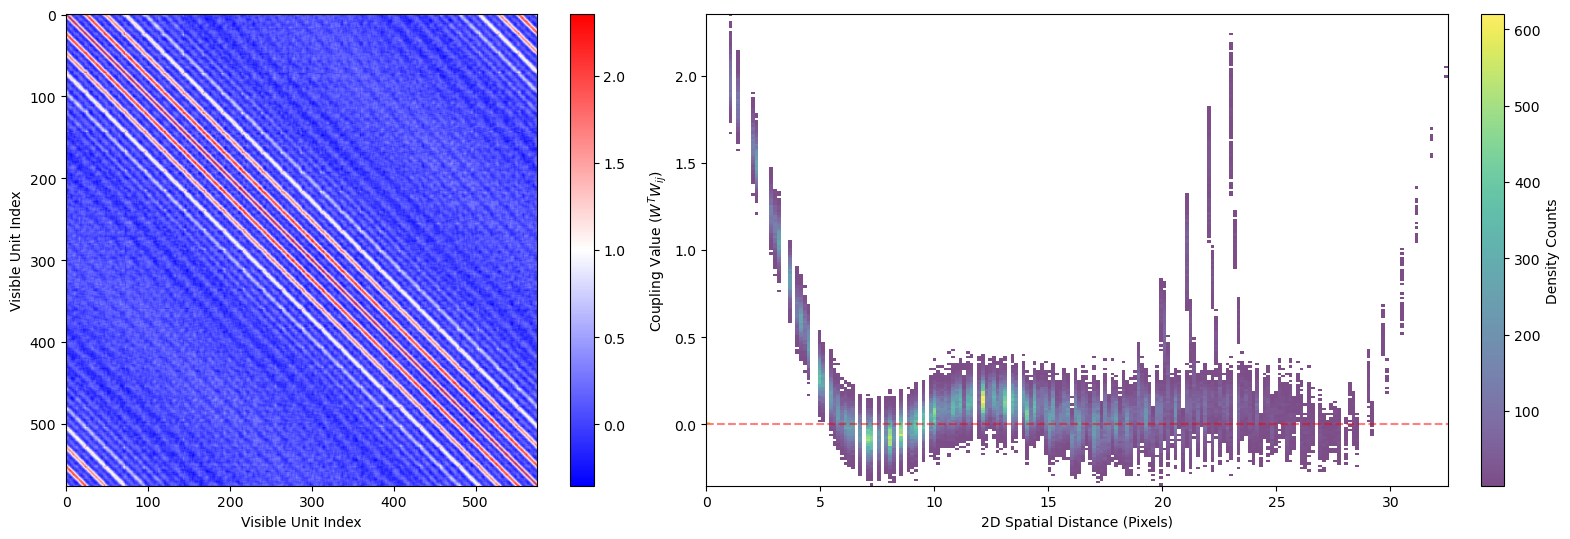

In [93]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

def analyze_physical_hamiltonian(W, grid_shape=None):
    """
    Visualizes the physical Hamiltonian coupling matrix (W^T * W) 
    and plots its interaction strengths as a function of real 2D spatial distance.
    
    Parameters:
        W: jnp.array or np.array, the weight matrix of shape (n_hidden, n_visible)
        grid_shape: tuple (height, width), spatial dimensions of your visible layer.
                    If None, assumes a square grid based on n_visible.
    """
    # 1. Convert JAX array to standard NumPy for plotting
    W_np = np.array(W)
    n_hidden, n_visible = W_np.shape
    
    if grid_shape is None:
        side = int(np.sqrt(n_visible))
        grid_shape = (side, side)
        assert grid_shape[0] * grid_shape[1] == n_visible, \
            f"Visible dimension {n_visible} is not a perfect square. Please specify grid_shape."

    # 2. Compute the physical Hamiltonian coupling matrix (W^T * W)
    # This represents the effective quadratic interactions between pixels
    J_physical = np.dot(W_np.T, W_np)
    np.fill_diagonal(J_physical, 0)  # Zero out self-interactions to isolate couplings

    # 3. Map visible units to actual 2D spatial coordinates
    x = np.arange(grid_shape[1])
    y = np.arange(grid_shape[0])
    X, Y = np.meshgrid(x, y)
    coordinates = np.vstack([Y.ravel(), X.ravel()]).T  # Shape: (n_visible, 2)

    # 4. Compute all pairwise 2D Euclidean distances between units
    distances = cdist(coordinates, coordinates, metric='euclidean')

    # Flatten both matrices to 1D arrays of length (n_visible * n_visible)
    flat_distances = distances.ravel()
    flat_couplings = J_physical.ravel()

    # ─── Plotting ─────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(18, 5.5))
    
    # Plot 1: The full Physical Hamiltonian Matrix
    im1 = axes[0].imshow(J_physical, cmap='bwr', aspect='equal')
    #axes[0].set_title(f"Physical Hamiltonian ($W^TW$)\nShape: {J_physical.shape}")
    axes[0].set_xlabel("Visible Unit Index")
    axes[0].set_ylabel("Visible Unit Index")
    fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

    # Plot 2: Coupling Strength vs 2D Distance Histogram
    counts, xedges, yedges, im2 = axes[1].hist2d(flat_distances, 
                                                 flat_couplings, bins=200, 
                                                 cmap='viridis', cmin=1,alpha=0.7)
    axes[1].axhline(0, color='red', linestyle='--', alpha=0.5)
    #axes[1].set_title("Interaction Strength vs. Spatial Distance")
    axes[1].set_xlabel("2D Spatial Distance (Pixels)")
    axes[1].set_ylabel("Coupling Value ($W^TW_{ij}$)")
    fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04, label="Density Counts")
    
    plt.tight_layout()
    plt.show()

# Invoke it directly using your structural dimensions:
# analyze_physical_hamiltonian(W, grid_shape=(28, 28))

# Example invocation (replace W with your actual trained JAX weight matrix):
analyze_physical_hamiltonian(W)

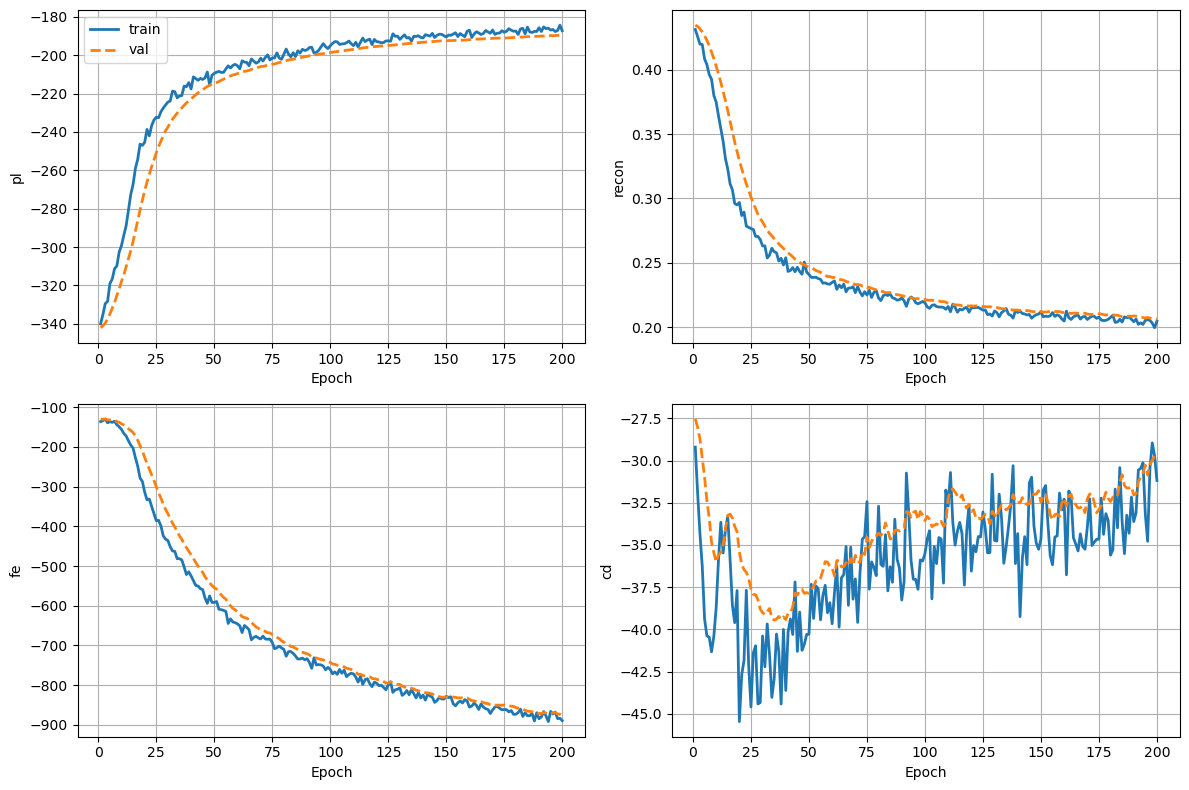

In [95]:
import matplotlib.pyplot as plt

def plot_metrics(history, metric_keys=("pl", "recon", "fe", "cd")):
    """
    Plots training and validation EWMA metrics over epochs.
    
    Parameters
    ----------
    history : list of dicts
        Each dict has 'epoch', 'train', 'val' keys.
    metric_keys : tuple
        The metrics to plot.
    """
    epochs = [h["epoch"] for h in history]
    
    plt.figure(figsize=(12, 8))
    
    for i, k in enumerate(metric_keys, 1):
        plt.subplot(2, 2, i)
        
        train_vals = [h["train"][k] for h in history]
        val_vals   = [h["val"][k]   for h in history]
        
        plt.plot(epochs, train_vals, label="train", lw=2)
        plt.plot(epochs, val_vals,   label="val",   lw=2, ls="--")
        
        #plt.title(k)
        plt.xlabel("Epoch")
        plt.ylabel(k)
        plt.grid(True)
        if i == 1:
            plt.legend()
    
    plt.tight_layout()
    plt.savefig('rbmpptraining.pdf')
    plt.show()

plot_metrics(history)

In [ ]:
# ── Generate ──
samples = generate(W, bv, bh, n_samples=8, gibbs_steps=100, rng=rng)
print(f"\nGenerated: {samples.shape}")
np.save("generated.npy", samples)

In [58]:
W.shape

(256, 576)